<a href="https://colab.research.google.com/github/kishita21/MLDL/blob/main/EXP8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

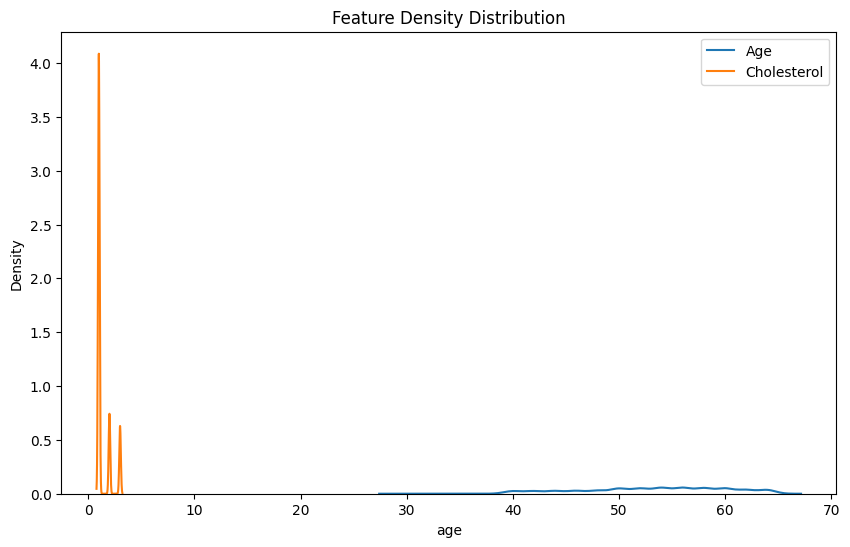

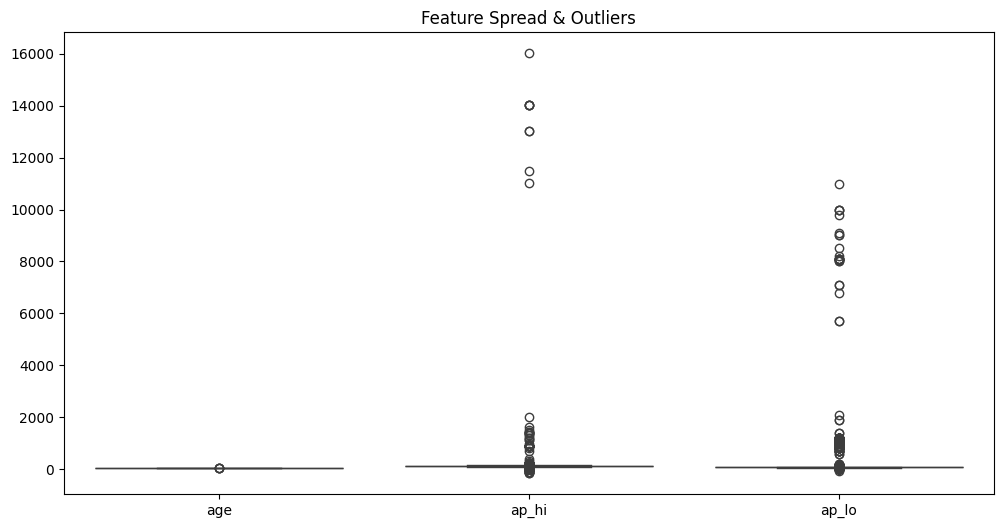

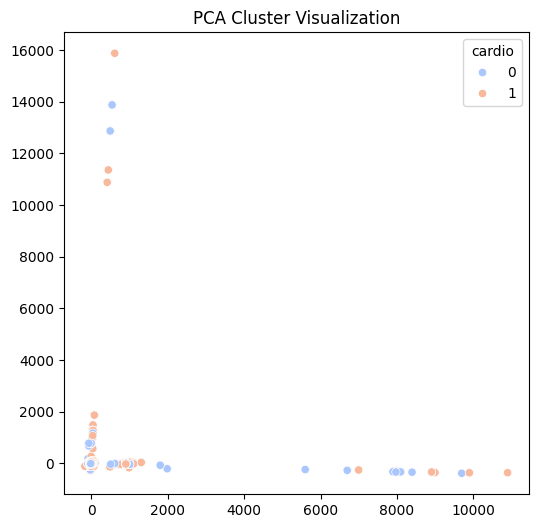

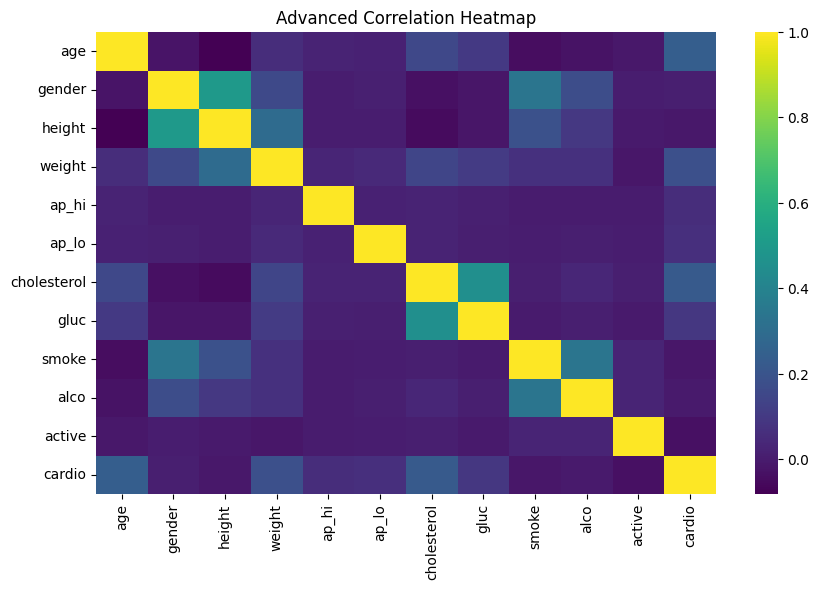

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6972 - loss: 0.5884 - val_accuracy: 0.7170 - val_loss: 0.5640
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7258 - loss: 0.5570 - val_accuracy: 0.7234 - val_loss: 0.5593
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7285 - loss: 0.5523 - val_accuracy: 0.7274 - val_loss: 0.5531
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7294 - loss: 0.5503 - val_accuracy: 0.7222 - val_loss: 0.5547
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7323 - loss: 0.5488 - val_accuracy: 0.7246 - val_loss: 0.5527
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7304 - loss: 0.5477 - val_accuracy: 0.7271 - val_loss: 0.5515
Epoch 7/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7319 - loss: 0.5466 - val_accuracy: 0.7259 - val_loss: 0.5517
Epoch 8/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7319 - loss: 0.5465 - val_accurac

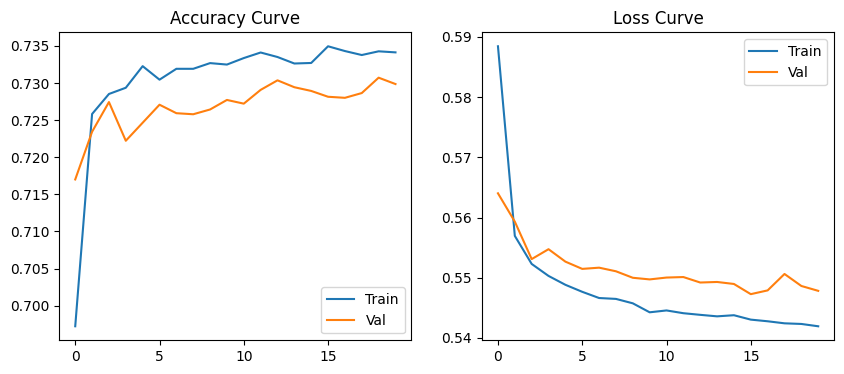

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


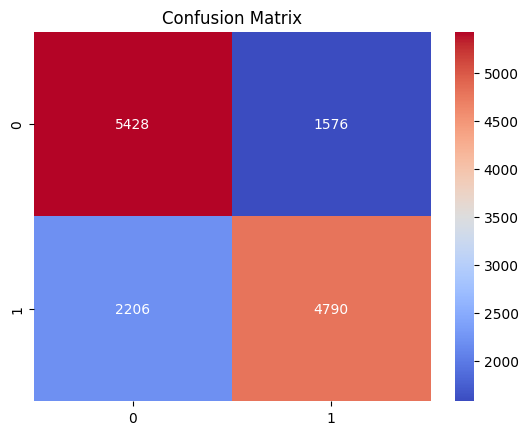

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


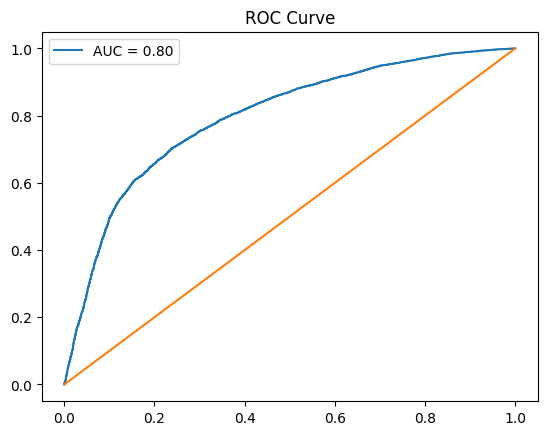

              precision    recall  f1-score   support

           0       0.71      0.77      0.74      7004
           1       0.75      0.68      0.72      6996

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000



In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.decomposition import PCA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv('/content/cardio_train.csv', sep=';')

# CLEAN
df = df.drop('id', axis=1)
df['age'] = df['age'] / 365

# ==============================
# 🔥 ADVANCED VISUALS (DIFFERENT)
# ==============================

# 1. KDE DISTRIBUTION (smooth)
plt.figure(figsize=(10,6))
sns.kdeplot(df['age'], label='Age')
sns.kdeplot(df['cholesterol'], label='Cholesterol')
plt.legend()
plt.title("Feature Density Distribution")
plt.show()

# 2. BOXPLOT (outliers)
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['age','ap_hi','ap_lo']])
plt.title("Feature Spread & Outliers")
plt.show()

# 3. PCA (colored clusters 🔥)
X_temp = df.drop('cardio', axis=1)
y_temp = df['cardio']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_temp)

plt.figure(figsize=(6,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_temp, palette='coolwarm')
plt.title("PCA Cluster Visualization")
plt.show()

# 4. CORRELATION (premium style)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='viridis')
plt.title("Advanced Correlation Heatmap")
plt.show()

# ==============================
# PREPROCESSING
# ==============================
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# RESHAPE for CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# ==============================
# CNN MODEL
# ==============================
model = Sequential()

model.add(Conv1D(32, 2, activation='relu', input_shape=(X_train.shape[1],1)))
model.add(MaxPooling1D(2))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ==============================
# TRAIN
# ==============================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# ==============================
# 📈 ADVANCED TRAINING GRAPH
# ==============================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss Curve")
plt.legend()

plt.show()

# ==============================
# PREDICTION
# ==============================
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

# ==============================
# CONFUSION MATRIX (STYLED)
# ==============================
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.show()

# ==============================
# ROC CURVE (🔥 EXTRA MARKS)
# ==============================
y_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.legend()
plt.show()

# ==============================
# REPORT
# ==============================
print(classification_report(y_test, y_pred))